# 基于 ViT/CLIP 特征与自实现 Transformer Decoder 的图像描述生成

## 0. Image Captioning

### What is Image Captioning?

- Image Captioning 是为图像自动生成文本描述的任务，需要同时使用计算机视觉和自然语言处理技术。
- 典型图像描述系统使用 Encoder-Decoder 框架：Encoder将输入图像编码为中间特征表示，Decoder根据图像特征逐词生成描述文本。
- 本实验采用更现代的 Transformer 路线：冻结预训练图像 encoder，学生自己实现 Transformer Decoder，包括 masked self-attention、image cross-attention、greedy decoding 和 beam search decoding 等细节。
- 本实验重点不是直接调用现成 image captioning 大模型，而是理解并实现 caption 生成中真正关键的文本建模和解码细节。

![Image Captioning](assets/imcaption.png)


## Encoder 路线说明

本实验的caption生成能力来自你实现并训练的Transformer Decoder。图像Encoder只作为冻结特征提取器,不参与训练。详细结构图如下：

![ViT/CLIP + Transformer Decoder Architecture](assets/vit_clip_transformer_caption_architecture.svg)


- `ENCODER_BACKBONE = 'torchvision_vit'`：使用 torchvision 的 ViT-B/16，权重来自 ImageNet-1K 分类预训练。代码使用新版 torchvision 权重枚举接口 `ViT_B_16_Weights.DEFAULT`。它不是图文对齐模型，优点是依赖简单、稳定。
- `ENCODER_BACKBONE = 'clip_vit_b32'`：使用 OpenAI CLIP ViT-B/32 image encoder，权重来自图文对比学习预训练。它更适合视觉语言任务，但依赖 `transformers` 并需要下载 Hugging Face 权重；代码使用新版 `CLIPImageProcessor`。

如果在线下载 torchvision ViT 权重太慢，可以手工下载 ViT-B/16 的 `.pth` 权重到当前工作目录 `./vit_b_16-c867db91.pth`，然后设置 `USE_LOCAL_TORCHVISION_VIT=True`。

如果在线下载 CLIP 太慢，可以手工下载 `openai/clip-vit-base-patch32`。本 notebook 支持两种本地格式：普通模型目录 `./clip-vit-base-patch32/`，或 Hugging Face 目录 `./models/hub/`。设置 `USE_LOCAL_CLIP=True` 后会自动解析到可加载的 snapshot 目录。

使用 CLIP encoder 时，本实验将 `last_hidden_state` 中的 CLS token 和 patch tokens 一起作为 cross-attention 的 visual memory，而不是只使用一个 `pooler_output` 全局向量。这样 decoder 可以从多个图像 token 中选择信息，通常比单向量 cross-attention 更有效。

In [5]:
import math
import random
import re
from collections import Counter
from pathlib import Path
from textwrap import wrap

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torchvision.models import vit_b_16, ViT_B_16_Weights
from transformers import CLIPImageProcessor, CLIPVisionModel

try:
    from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
except Exception:
    corpus_bleu = None
    SmoothingFunction = None

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif getattr(torch.backends, 'mps', None) and torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')
    

print('device =', DEVICE)
if DEVICE.type == 'cuda':
    print('gpu =', torch.cuda.get_device_name(0))


device = mps


## 1. 实验配置

第一次运行保持 `FAST_DEV_RUN=True`。正式实验时改为 `False`，并根据显存调整 batch size。

In [6]:
FAST_DEV_RUN = False

DATA_ROOT = Path('./flickr8k')
IMAGE_DIR = DATA_ROOT / 'Images'
CAPTION_FILE = DATA_ROOT / 'captions.txt'
# FAST_DEV_RUN=True 时用小样本快速调试；正式实验时按图像数量 80/10/10 划分，
# 同一张图的全部 5 条 caption 归入同一子集，避免数据泄露。
if FAST_DEV_RUN:
    TRAIN_SIZE = 60
    VAL_SIZE = 10
    TEST_SIZE = 10
else:
    TRAIN_SIZE = None   # 由实际数据决定
    VAL_SIZE = None
    TEST_SIZE = None

MIN_WORD_FREQ = 2 if FAST_DEV_RUN else 5
MAX_LEN = 32
BATCH_SIZE = 8 if FAST_DEV_RUN else 32
EPOCHS = 1 if FAST_DEV_RUN else 15
LEARNING_RATE = 3e-4

# 基础版：'torchvision_vit'，使用 ImageNet-1K 分类预训练 ViT。
# 提高版：'clip_vit_b32'，使用 CLIP 图文对比学习预训练 image encoder。
ENCODER_BACKBONE = 'clip_vit_b32'
# 如果在线下载 torchvision ViT 权重太慢，可以手工下载 .pth 文件到该路径，然后设置 USE_LOCAL_TORCHVISION_VIT=True。
USE_LOCAL_TORCHVISION_VIT = True
LOCAL_TORCHVISION_VIT_WEIGHTS = Path('./models/vit_b_16-c867db91.pth')
CLIP_MODEL_NAME = 'openai/clip-vit-base-patch32'
# 如果在线下载太慢，可以手工下载 CLIP 模型文件到该目录，然后设置 USE_LOCAL_CLIP=True。
USE_LOCAL_CLIP = True
LOCAL_CLIP_MODEL_DIR = Path('./models/hub')


D_MODEL = 256
NUM_LAYERS = 2
NUM_HEADS = 4
FFN_DIM = 512
DROPOUT = 0.3

PAD = '<PAD>'
UNK = '<UNK>'
BOS = '<BOS>'
EOS = '<EOS>'
SPECIAL_TOKENS = [PAD, UNK, BOS, EOS]

assert IMAGE_DIR.exists(), f'Image directory not found: {IMAGE_DIR.resolve()}'
assert CAPTION_FILE.exists(), f'Caption file not found: {CAPTION_FILE.resolve()}'

## Encoder 路线说明

本实验的 caption 生成能力来自你实现并训练的 Transformer Decoder。图像 encoder 只作为冻结特征提取器。

![ViT/CLIP + Transformer Decoder Architecture](assets/vit_clip_transformer_caption_architecture.svg)


- `ENCODER_BACKBONE = 'torchvision_vit'`：使用 torchvision 的 ViT-B/16，权重来自 ImageNet-1K 分类预训练。代码使用新版 torchvision 权重枚举接口 `ViT_B_16_Weights.DEFAULT`。它不是图文对齐模型，优点是依赖简单、稳定。
- `ENCODER_BACKBONE = 'clip_vit_b32'`：使用 OpenAI CLIP ViT-B/32 image encoder，权重来自图文对比学习预训练。它更适合视觉语言任务，但依赖 `transformers` 并需要下载 Hugging Face 权重；代码使用新版 `CLIPImageProcessor`。


如果在线下载 torchvision ViT 权重太慢，可以手工下载 ViT-B/16 的 `.pth` 权重到当前工作目录 `./vit_b_16-c867db91.pth`，然后设置 `USE_LOCAL_TORCHVISION_VIT=True`。

如果在线下载 CLIP 太慢，可以手工下载 `openai/clip-vit-base-patch32`。本 notebook 支持两种本地格式：普通模型目录 `./clip-vit-base-patch32/`，或 Hugging Face 缓存目录 `./models/hub/`。设置 `USE_LOCAL_CLIP=True` 后会自动解析到可加载的 snapshot 目录。

使用 CLIP encoder 时，本实验将 `last_hidden_state` 中的 CLS token 和 patch tokens 一起作为 cross-attention 的 visual memory，而不是只使用一个 `pooler_output` 全局向量。这样 decoder 可以从多个图像 token 中选择信息，通常比单向量 cross-attention 更有效。


## 2. Caption 文本预处理、Vocabulary、Tokenization 与 Encoding


图像描述任务不仅需要处理图片，还必须把自然语言 caption 转成模型可以学习的 token 序列。

我们将完成：

- 读取 Flickr8k 的 `captions.txt`。
- 统计 caption 长度，验证 `MAX_LEN=32` 是否合理。
- 文本清洗：转小写、处理标点、压缩空格。
- 统计词频，观察高频词和低频词。
- 构建 vocabulary：低频词用 `<UNK>` 表示。
- 将 caption 编码成固定长度 token ids：`<BOS> ... <EOS> <PAD> ...`。

![Tokenization](assets/tocken.gif)

Flickr8k 样例可视化如下，本 notebook 后面还会从当前划分出的训练集中动态抽样显示图片和 caption。

![Flickr8k Samples](assets/samples.png)




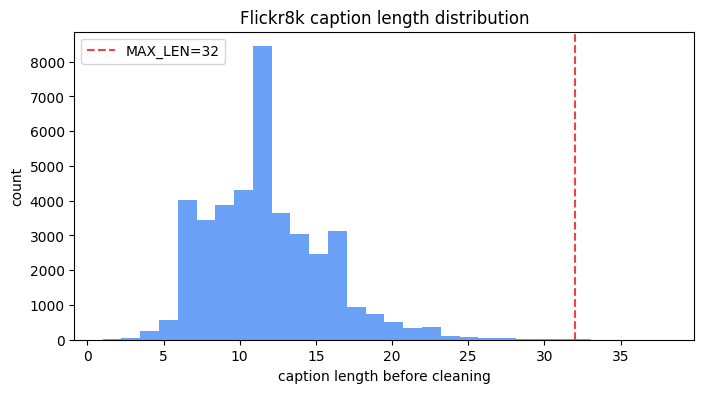

Cleaned caption examples:


,image,raw_caption,caption,length
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...,a child in a pink dress is climbing up a set o...,17
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .,a girl going into a wooden building,7
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .,a little girl climbing into a wooden playhouse,8
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...,a little girl climbing the stairs to her playh...,9
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...,a little girl in a pink dress going into a woo...,12


raw caption rows: 40455
unique images: 8091
train / val / test captions: 32360 4045 4050


,image,caption,raw_caption,raw_length,length
0,1000268201_693b08cb0e.jpg,a child in a pink dress is climbing up a set o...,A child in a pink dress is climbing up a set o...,18,17
1,1000268201_693b08cb0e.jpg,a girl going into a wooden building,A girl going into a wooden building .,8,7
2,1000268201_693b08cb0e.jpg,a little girl climbing into a wooden playhouse,A little girl climbing into a wooden playhouse .,9,8
3,1000268201_693b08cb0e.jpg,a little girl climbing the stairs to her playh...,A little girl climbing the stairs to her playh...,10,9
4,1000268201_693b08cb0e.jpg,a little girl in a pink dress going into a woo...,A little girl in a pink dress going into a woo...,13,12


In [7]:
def clean_caption(text: str) -> str:
    """Lowercase and remove punctuation-like characters.

    We replace punctuation with spaces instead of deleting it directly, so
    expressions such as "black-and-white" become "black and white" instead of
    "blackandwhite". This usually reduces unnecessary <UNK> tokens.
    """
    text = str(text).lower().strip()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

raw_df = pd.read_csv(CAPTION_FILE)
raw_df.columns = [c.strip() for c in raw_df.columns]
raw_df['raw_caption'] = raw_df['caption'].astype(str)
raw_df['raw_length'] = raw_df['raw_caption'].apply(lambda row: len(row.strip().split()))

plt.figure(figsize=(8, 4))
plt.hist(raw_df['raw_length'], bins=30, color='#3b82f6', alpha=0.75)
plt.axvline(MAX_LEN, color='#ef4444', linestyle='--', label=f'MAX_LEN={MAX_LEN}')
plt.xlabel('caption length before cleaning')
plt.ylabel('count')
plt.title('Flickr8k caption length distribution')
plt.legend()
plt.show()

raw_df['caption'] = raw_df['raw_caption'].map(clean_caption)
raw_df['length'] = raw_df['caption'].apply(lambda row: len(row.strip().split()))
raw_df = raw_df[raw_df['image'].map(lambda x: (IMAGE_DIR / x).exists())].copy()

print('Cleaned caption examples:')
display(raw_df[['image', 'raw_caption', 'caption', 'length']].head())

# 按图像划分数据集（同一张图的全部 5 条 caption 归入同一子集），避免数据泄露
unique_images = raw_df['image'].unique()
unique_images = np.array([img for img in unique_images if (IMAGE_DIR / img).exists()])
rng = np.random.RandomState(SEED)
rng.shuffle(unique_images)

if FAST_DEV_RUN:
    need = TRAIN_SIZE + VAL_SIZE + TEST_SIZE
    subset_images = unique_images[:need]
    train_images = subset_images[:TRAIN_SIZE]
    val_images = subset_images[TRAIN_SIZE:TRAIN_SIZE + VAL_SIZE]
    test_images = subset_images[TRAIN_SIZE + VAL_SIZE:]
else:
    n_total = len(unique_images)
    n_train = int(n_total * 0.8)
    n_val = int(n_total * 0.1)
    n_test = n_total - n_train - n_val
    train_images = unique_images[:n_train]
    val_images = unique_images[n_train:n_train + n_val]
    test_images = unique_images[n_train + n_val:]

train_df = raw_df[raw_df['image'].isin(train_images)].reset_index(drop=True)
val_df = raw_df[raw_df['image'].isin(val_images)].reset_index(drop=True)
test_df = raw_df[raw_df['image'].isin(test_images)].reset_index(drop=True)

print('raw caption rows:', len(raw_df))
print('unique images:', len(unique_images))
print('train / val / test captions:', len(train_df), len(val_df), len(test_df))
train_df.head()

In [8]:
def count_words(captions):
    counter = Counter()
    for caption in captions:
        counter.update(caption.strip().split())
    return counter

word_counter = count_words(train_df['caption'].tolist())
print('Top 30 frequent words:')
display(pd.DataFrame(word_counter.most_common(30), columns=['word', 'count']))
print('30 rare words:')
display(pd.DataFrame(sorted(word_counter.items(), key=lambda item: item[1])[:30], columns=['word', 'count']))


def build_vocab(captions, min_freq=5):
    """Build token vocabulary from cleaned captions.

    Special tokens:
    - <PAD>: padding positions that should not contribute to loss.
    - <UNK>: out-of-vocabulary words filtered by min_freq.
    - <BOS>: beginning of sentence, used as the first decoder input.
    - <EOS>: end of sentence, used to stop generation.
    """
    counter = count_words(captions)
    itos = list(SPECIAL_TOKENS)
    for word, freq in counter.most_common():
        if freq >= min_freq and word not in itos:
            itos.append(word)
    stoi = {tok: idx for idx, tok in enumerate(itos)}
    return stoi, itos, counter

stoi, itos, word_counter = build_vocab(train_df['caption'].tolist(), MIN_WORD_FREQ)
PAD_IDX = stoi[PAD]
UNK_IDX = stoi[UNK]
BOS_IDX = stoi[BOS]
EOS_IDX = stoi[EOS]
VOCAB_SIZE = len(itos)

print('special token ids:', {tok: stoi[tok] for tok in SPECIAL_TOKENS})
print('vocab size =', VOCAB_SIZE)
print('min word frequency =', MIN_WORD_FREQ)

Top 30 frequent words:


,word,count
0,a,50704
1,in,15150
2,the,14656
3,on,8700
4,is,7474
5,and,7070
6,dog,6420
7,with,6203
8,man,5794
9,of,5368


30 rare words:


,word,count
0,entry,1
1,aross,1
2,belays,1
3,crampons,1
4,scale,1
5,gentle,1
6,snaps,1
7,captures,1
8,tin,1
9,moutains,1


special token ids: {'<PAD>': 0, '<UNK>': 1, '<BOS>': 2, '<EOS>': 3}
vocab size = 2659
min word frequency = 5


In [9]:
def encode_caption(text, max_len=MAX_LEN):
    """Convert one cleaned caption string to fixed-length token ids.

    Format: <BOS> word_1 word_2 ... <EOS> <PAD> ...
    Words not found in stoi are encoded as <UNK>.
    """
    ids = [BOS_IDX]
    ids += [stoi.get(tok, UNK_IDX) for tok in text.split()]
    ids += [EOS_IDX]
    ids = ids[:max_len]
    if len(ids) < max_len:
        ids += [PAD_IDX] * (max_len - len(ids))
    return ids


def decode_ids(ids):
    """Convert token ids back to readable text for debugging and generation."""
    words = []
    for idx in ids:
        idx = int(idx)
        if idx == EOS_IDX:
            break
        if idx in (PAD_IDX, BOS_IDX):
            continue
        words.append(itos[idx] if idx < len(itos) else UNK)
    return ' '.join(words)

example_caption = train_df.iloc[0]['caption']
example_ids = encode_caption(example_caption)
print('caption:', example_caption)
print('token ids:', example_ids[:16])
print('decoded :', decode_ids(example_ids))
print('tokens  :', [itos[i] if i < len(itos) else UNK for i in example_ids[:16]])

caption: a child in a pink dress is climbing up a set of stairs in an entry way
token ids: [2, 4, 42, 5, 4, 84, 172, 8, 123, 52, 4, 390, 13, 416, 5, 29]
decoded : a child in a pink dress is climbing up a set of stairs in an <UNK> way
tokens  : ['<BOS>', 'a', 'child', 'in', 'a', 'pink', 'dress', 'is', 'climbing', 'up', 'a', 'set', 'of', 'stairs', 'in', 'an']


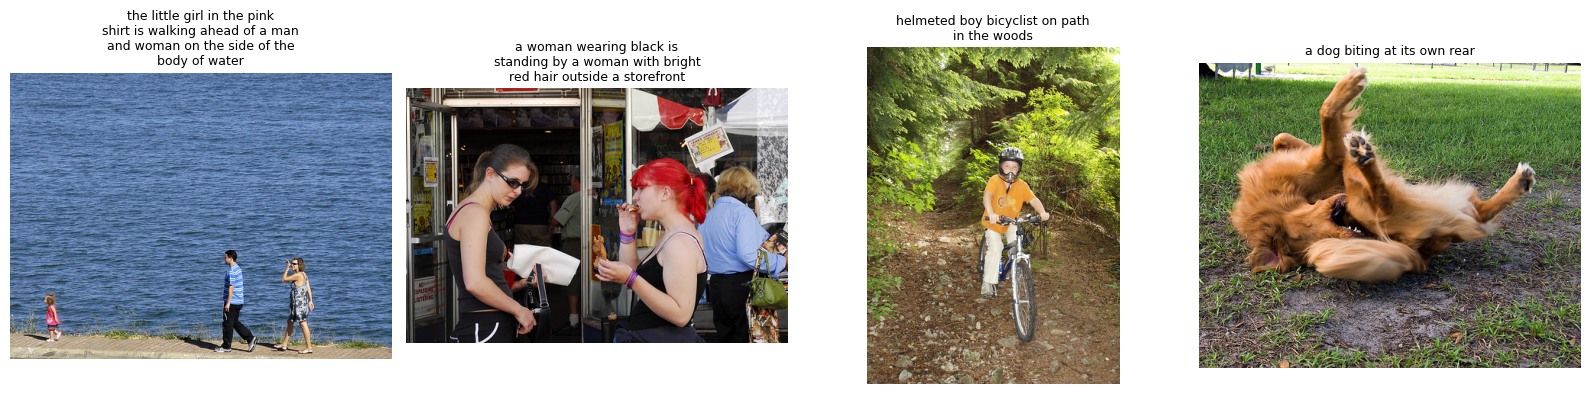

In [10]:
def show_samples(df, n=4):
    """Visualize sample images with their cleaned captions."""
    n = min(n, len(df))
    fig, axes = plt.subplots(1, n, figsize=(4*n, 4))
    if n == 1:
        axes = [axes]
    for ax, (_, row) in zip(axes, df.sample(n, random_state=SEED).iterrows()):
        img = Image.open(IMAGE_DIR / row['image']).convert('RGB')
        ax.imshow(img)
        title = '\n'.join(wrap(row['caption'], width=32))
        ax.set_title(title, fontsize=9)
        ax.axis('off')
    plt.tight_layout()

show_samples(train_df, 4)

## 3. Dataset 与 DataLoader

训练时使用 teacher forcing：输入为 `<BOS> w1 w2 ...`，预测目标为 `w1 w2 ... <EOS>`。


In [12]:

def resolve_clip_local_dir(path):
    """Resolve a local CLIP path for from_pretrained.

    Supported layouts:
    1. A normal model directory, e.g. ./clip-vit-base-patch32 containing
       config.json, preprocessor_config.json, and pytorch_model.bin/model.safetensors.
    2. A Hugging Face cache root, e.g. ./models/hub containing
       models--openai--clip-vit-base-patch32/snapshots/<commit-hash>/.
    3. The model cache directory itself, e.g.
       ./models/hub/models--openai--clip-vit-base-patch32.
    """
    path = Path(path)
    if (path / 'config.json').exists() and (path / 'preprocessor_config.json').exists():
        return path

    model_cache = path
    if path.name != 'models--openai--clip-vit-base-patch32':
        model_cache = path / 'models--openai--clip-vit-base-patch32'

    snapshots = model_cache / 'snapshots'
    if not snapshots.exists():
        raise FileNotFoundError(
            f'Cannot find a CLIP model directory or Hugging Face cache snapshots under: {path}'
        )

    candidates = []
    for snapshot in sorted(snapshots.iterdir()):
        if not snapshot.is_dir():
            continue
        has_config = (snapshot / 'config.json').exists()
        has_preprocessor = (snapshot / 'preprocessor_config.json').exists()
        has_weights = (snapshot / 'pytorch_model.bin').exists() or (snapshot / 'model.safetensors').exists()
        if has_config and has_preprocessor and has_weights:
            candidates.append(snapshot)

    if not candidates:
        raise FileNotFoundError(
            f'No complete CLIP snapshot found under {snapshots}. '
            'Need config.json, preprocessor_config.json, and pytorch_model.bin or model.safetensors.'
        )
    return candidates[-1]


def build_image_transform(encoder_backbone):
    if encoder_backbone == 'torchvision_vit':
        weights = ViT_B_16_Weights.DEFAULT
        return weights.transforms()
    if encoder_backbone == 'clip_vit_b32':
        clip_source = str(resolve_clip_local_dir(LOCAL_CLIP_MODEL_DIR)) if USE_LOCAL_CLIP else CLIP_MODEL_NAME
        processor = CLIPImageProcessor.from_pretrained(clip_source, local_files_only=USE_LOCAL_CLIP)
        def transform(image):
            return processor(images=image, return_tensors='pt')['pixel_values'][0]
        return transform
    raise ValueError(f'unknown ENCODER_BACKBONE: {encoder_backbone}')

image_transform = build_image_transform(ENCODER_BACKBONE)
print('encoder backbone =', ENCODER_BACKBONE)

class FlickrCaptionDataset(Dataset):
    def __init__(self, df, image_dir, transform):
        self.df = df.reset_index(drop=True)
        self.image_dir = Path(image_dir)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(self.image_dir / row['image']).convert('RGB')
        image = self.transform(image)
        token_ids = torch.tensor(encode_caption(row['caption']), dtype=torch.long)
        return image, token_ids, row['caption'], row['image']


def collate_fn(batch):
    images, token_ids, captions, image_names = zip(*batch)
    images = torch.stack(images)
    token_ids = torch.stack(token_ids)
    decoder_input = token_ids[:, :-1]
    target = token_ids[:, 1:]
    return images, decoder_input, target, captions, image_names

train_loader = DataLoader(FlickrCaptionDataset(train_df, IMAGE_DIR, image_transform), batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(FlickrCaptionDataset(val_df, IMAGE_DIR, image_transform), batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(FlickrCaptionDataset(test_df, IMAGE_DIR, image_transform), batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

images, decoder_input, target, captions, image_names = next(iter(train_loader))
print(images.shape, decoder_input.shape, target.shape)


encoder backbone = clip_vit_b32
torch.Size([32, 3, 224, 224]) torch.Size([32, 31]) torch.Size([32, 31])


## 4. ViT 图像编码器（ViT Image Encoder）-- 冻结状态

本实验提供两种冻结的视觉 Transformer encoder。它们负责把图像转换成 visual memory，但不参与梯度更新；真正需要训练和实现的是后面的 Transformer Caption Decoder。

### 4.1 torchvision ViT-B/16 Encoder

该路线使用 ImageNet-1K 分类预训练的 ViT-B/16。分类 head 被替换为 `Identity`，当前代码取一个全局 CLS 特征，并转换为 `[B, 1, 768]` 的 visual memory。

![torchvision ViT-B/16 Encoder](assets/torchvision_vit_encoder.svg)

### 4.2 CLIP ViT-B/32 Image Encoder

该路线使用图文对比学习预训练的 CLIP vision encoder。当前代码读取 `last_hidden_state`，保留 CLS token 和全部 patch tokens，得到约 `[B, 50, 768]` 的 visual memory，供 Decoder 的 cross-attention 使用。

![CLIP ViT-B/32 Image Encoder](assets/clip_vit_encoder.svg)

注意：CLIP 的文本 encoder 只参与原始 CLIP 对比预训练，本实验训练 caption 时不会调用 CLIP text encoder。


In [13]:
class FrozenTorchvisionViTEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        if USE_LOCAL_TORCHVISION_VIT:
            self.vit = vit_b_16(weights=None)
            checkpoint = torch.load(LOCAL_TORCHVISION_VIT_WEIGHTS, map_location='cpu')
            state_dict = checkpoint.get('state_dict', checkpoint) if isinstance(checkpoint, dict) else checkpoint
            self.vit.load_state_dict(state_dict)
        else:
            weights = ViT_B_16_Weights.DEFAULT
            self.vit = vit_b_16(weights=weights)
        self.vit.heads = nn.Identity()
        for p in self.vit.parameters():
            p.requires_grad = False
        self.out_dim = 768
        self.pretraining = 'ImageNet-1K supervised classification'

    def forward(self, images):
        self.vit.eval()
        with torch.no_grad():
            feats = self.vit(images)
        return feats.unsqueeze(1)

class FrozenCLIPVisionEncoder(nn.Module):
    def __init__(self, model_name=CLIP_MODEL_NAME):
        super().__init__()
        clip_source = str(resolve_clip_local_dir(LOCAL_CLIP_MODEL_DIR)) if USE_LOCAL_CLIP else model_name
        self.clip = CLIPVisionModel.from_pretrained(clip_source, local_files_only=USE_LOCAL_CLIP)
        for p in self.clip.parameters():
            p.requires_grad = False
        self.out_dim = self.clip.config.hidden_size
        self.pretraining = 'CLIP image-text contrastive pretraining'

    def forward(self, images):
        self.clip.eval()
        with torch.no_grad():
            outputs = self.clip(pixel_values=images)
            # Use CLS + patch tokens as visual memory, not just one pooled vector.
            # For CLIP ViT-B/32 this is usually [B, 50, 768].
            feats = outputs.last_hidden_state
        return feats


def build_frozen_encoder(encoder_backbone):
    if encoder_backbone == 'torchvision_vit':
        return FrozenTorchvisionViTEncoder()
    if encoder_backbone == 'clip_vit_b32':
        return FrozenCLIPVisionEncoder()
    raise ValueError(f'unknown ENCODER_BACKBONE: {encoder_backbone}')

encoder = build_frozen_encoder(ENCODER_BACKBONE).to(DEVICE)
encoder.eval()
with torch.no_grad():
    feats = encoder(images.to(DEVICE))
print('encoder pretraining:', encoder.pretraining)
print('image features:', feats.shape)


encoder pretraining: CLIP image-text contrastive pretraining
image features: torch.Size([32, 50, 768])


## 5. 自实现 Transformer Decoder

**_下面实现 causal mask、scaled dot-product attention、multi-head attention、decoder block 和完整 caption 模型。（学生需完成 TODOs）_**


下图展示了学生手工实现的 Transformer Decoder 的详细结构（Pre-LN），包括两次堆叠的 Decoder Block、每一层内的 Masked Self-Attention、Cross-Attention 和 FFN，以及输入输出流程。

![Student-built Transformer Decoder Detail](assets/decoder_classic_transformer.svg)


In [ ]:
def make_causal_mask(seq_len, device):
    """生成因果掩码，防止解码器看到未来词。
    TODO 1: 确认 diagonal=1 时上三角为 True，表示这些位置会被屏蔽。
    """
    mask = torch.triu(torch.ones(seq_len, seq_len, dtype=torch.bool, device=device), diagonal=1)
    return mask


def make_padding_mask(tokens, pad_idx=PAD_IDX):
    """标记 padding 位置，用于在 attention 中忽略 pad token。"""
    return tokens.eq(pad_idx)


def scaled_dot_product_attention(q, k, v, attn_mask=None, key_padding_mask=None, dropout=None):
    """计算 Scaled Dot-Product Attention。
    TODO 2: 检查 masked_fill 的广播维度是否与 scores 对齐。
    """
    d_k = q.size(-1)
    scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(d_k)
    if attn_mask is not None:
        scores = scores.masked_fill(attn_mask.unsqueeze(0).unsqueeze(0), float("-inf"))
    if key_padding_mask is not None:
        scores = scores.masked_fill(key_padding_mask.unsqueeze(1).unsqueeze(2), float("-inf"))
    attn = torch.softmax(scores, dim=-1)
    attn = torch.nan_to_num(attn, nan=0.0)
    if dropout is not None:
        attn = dropout(attn)
    out = torch.matmul(attn, v)
    return out, attn


class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, dropout=0.1):
        super().__init__()
        assert d_model % num_heads == 0
        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads
        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)
        self.attn_dropout = nn.Dropout(dropout)

    def split_heads(self, x):
        bsz, seq_len, _ = x.shape
        x = x.view(bsz, seq_len, self.num_heads, self.head_dim)
        return x.transpose(1, 2)

    def merge_heads(self, x):
        bsz, heads, seq_len, head_dim = x.shape
        x = x.transpose(1, 2).contiguous()
        return x.view(bsz, seq_len, heads * head_dim)

    def forward(self, query, key, value, attn_mask=None, key_padding_mask=None):
        # TODO 3: 实现 MultiHeadAttention 的 forward。
        # Hint: 1) 用 q_proj/k_proj/v_proj 对输入做线性投影；
        #       2) 用 split_heads 将 Q/K/V 分头；
        #       3) 调用 scaled_dot_product_attention 计算注意力输出与权重；
        #       4) 用 merge_heads 合并多头结果；
        #       5) 经过 out_proj 和 dropout 后返回 (out, attn)。
        raise NotImplementedError


In [ ]:
def get_sinusoidal_pos_embed(max_len, d_model):
    position = torch.arange(max_len).unsqueeze(1).float()
    div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
    pe = torch.zeros(max_len, d_model)
    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)
    return pe

class TransformerDecoderBlock(nn.Module):
    def __init__(self, d_model, num_heads, ffn_dim, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.cross_attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, ffn_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(ffn_dim, d_model),
            nn.Dropout(dropout),
        )
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)

    def forward(self, x, memory, causal_mask=None, tgt_padding_mask=None, memory_padding_mask=None):
        # TODO 4: 实现 Pre-LN 风格的 masked self-attention、cross-attention、FFN 三个残差块。
        # Hint: 先对 x 做 LayerNorm，再传入 attention，然后残差相加。
        raise NotImplementedError

class TransformerCaptionDecoder(nn.Module):
    def __init__(self, vocab_size, d_model, num_layers, num_heads, ffn_dim, max_len, image_feature_dim, dropout=0.1):
        super().__init__()
        self.token_embed = nn.Embedding(vocab_size, d_model, padding_idx=PAD_IDX)
        # sinusoidal positional encoding
        pe = get_sinusoidal_pos_embed(max_len, d_model)
        self.register_buffer('pos_embed', pe)
        self.image_proj = nn.Linear(image_feature_dim, d_model)
        self.layers = nn.ModuleList([
            TransformerDecoderBlock(d_model, num_heads, ffn_dim, dropout)
            for _ in range(num_layers)
        ])
        self.dropout = nn.Dropout(dropout)
        self.lm_head = nn.Linear(d_model, vocab_size)
        # 权重共享
        self.lm_head.weight = self.token_embed.weight
        self.max_len = max_len

    def forward(self, image_features, input_ids, return_attn=False):
        # TODO 5: token embedding + sinusoidal positional embedding；投影 image feature；逐层 decoder；输出 vocab logits。
        # 如果 return_attn=True，额外返回每层 cross-attention 的 attn_weights list。
        raise NotImplementedError

class ImageCaptionModel(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, images, input_ids, return_attn=False):
        image_features = self.encoder(images)
        return self.decoder(image_features, input_ids, return_attn=return_attn)

model = ImageCaptionModel(
    encoder=encoder,
    decoder=TransformerCaptionDecoder(VOCAB_SIZE, D_MODEL, NUM_LAYERS, NUM_HEADS, FFN_DIM, MAX_LEN, encoder.out_dim, DROPOUT),
).to(DEVICE)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f'trainable params: {trainable:,} / total params: {total:,}')

## 6. 训练与验证

In [ ]:
@torch.no_grad()
def generate_caption_greedy(model, image, max_len=MAX_LEN):
    model.eval()
    image = image.unsqueeze(0).to(DEVICE)
    generated = torch.tensor([[BOS_IDX]], dtype=torch.long, device=DEVICE)
    image_features = model.encoder(image)
    for _ in range(max_len - 1):
        logits = model.decoder(image_features, generated)
        next_id = logits[:, -1, :].argmax(dim=-1, keepdim=True)
        generated = torch.cat([generated, next_id], dim=1)
        if next_id.item() == EOS_IDX:
            break
    return decode_ids(generated.squeeze(0).cpu().tolist())


@torch.no_grad()
def evaluate_generation(model, df, limit=None):
    """Evaluate BLEU-4 on validation/test set using greedy decoding."""
    model.eval()
    ds = FlickrCaptionDataset(df, IMAGE_DIR, image_transform)
    refs, preds = [], []
    count = len(ds) if limit is None else min(limit, len(ds))
    for i in tqdm(range(count), desc='val_gen', leave=False):
        img_tensor, _, gt, _ = ds[i]
        pred = generate_caption_greedy(model, img_tensor)
        refs.append(gt)
        preds.append(pred)
    refs_tokenized = [[r.split()] for r in refs]
    preds_tokenized = [p.split() for p in preds]
    smooth = SmoothingFunction().method1
    bleu4 = corpus_bleu(refs_tokenized, preds_tokenized, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smooth)
    return bleu4, refs, preds


print('generate_caption_greedy and evaluate_generation ready.')

In [ ]:
def run_one_epoch(model, loader, optimizer=None, scheduler=None):
    is_train = optimizer is not None
    if is_train:
        model.decoder.train()
    else:
        model.eval()
    total_loss = 0.0
    total_tokens = 0
    pbar = tqdm(loader, leave=False)
    for images, decoder_input, target, _, _ in pbar:
        images = images.to(DEVICE)
        decoder_input = decoder_input.to(DEVICE)
        target = target.to(DEVICE)
        if is_train:
            optimizer.zero_grad(set_to_none=True)
        logits = model(images, decoder_input)
        # TODO 6: 使用 cross_entropy 计算 loss，忽略 PAD_IDX，加入 label_smoothing=0.1。
        loss = None
        if is_train:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            if scheduler is not None:
                scheduler.step()
        num = target.ne(PAD_IDX).sum().item()
        total_loss += loss.item() * num
        total_tokens += num
        pbar.set_postfix(loss=loss.item())
    return total_loss / max(total_tokens, 1)


# TODO 7: 设置 weight_decay=0.05，并使用 Warmup + Cosine 学习率调度
# Hint: total_steps = EPOCHS * len(train_loader); warmup_steps = int(0.1 * total_steps)
optimizer = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=LEARNING_RATE)
history = []
best_bleu = -1.0
best_state = None
patience = 3
patience_counter = 0

# 在每个 epoch 结束后用 greedy decoding 计算 val_bleu，用 BLEU 选最优模型并启用 Early Stopping
for epoch in range(EPOCHS):
    train_loss = run_one_epoch(model, train_loader, optimizer, scheduler)
    val_loss = run_one_epoch(model, val_loader, optimizer=None)
    val_bleu, _, _ = evaluate_generation(model, val_df, limit=None)

    history.append({'epoch': epoch + 1, 'train_loss': train_loss, 'val_loss': val_loss, 'val_bleu': val_bleu})
    print(f"epoch {epoch+1}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}, val_bleu={val_bleu:.4f}")

    if val_bleu > best_bleu:
        best_bleu = val_bleu
        best_state = model.state_dict().copy()
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch+1}. Restoring best val_bleu={best_bleu:.4f}")
        break

if best_state is not None:
    model.load_state_dict(best_state)

pd.DataFrame(history)

## 7. Greedy Decoding, Beam Search Decoding 以及部分样本可视化


In [ ]:
@torch.no_grad()
def generate_caption_beam_search(model, image, max_len=MAX_LEN, beam_width=3):
    model.eval()
    image = image.unsqueeze(0).to(DEVICE)
    image_features = model.encoder(image)
    sequences = [([BOS_IDX], 0.0)]

    for _ in range(max_len - 1):
        all_candidates = []
        for tokens, score in sequences:
            if tokens[-1] == EOS_IDX:
                all_candidates.append((tokens, score))
                continue
            generated = torch.tensor([tokens], dtype=torch.long, device=DEVICE)
            logits = model.decoder(image_features, generated)
            log_probs = torch.log_softmax(logits[:, -1, :], dim=-1)
            topk_log_probs, topk_ids = log_probs.topk(beam_width)
            for log_prob, token_id in zip(topk_log_probs[0], topk_ids[0]):
                new_tokens = tokens + [token_id.item()]
                new_score = score + log_prob.item()
                all_candidates.append((new_tokens, new_score))
        sequences = sorted(all_candidates, key=lambda x: x[1] / len(x[0]), reverse=True)[:beam_width]
        if all(t[-1] == EOS_IDX for t, _ in sequences):
            break

    best_tokens = sequences[0][0]
    return decode_ids(best_tokens)


sample_ds = FlickrCaptionDataset(test_df, IMAGE_DIR, image_transform)
for i in range(min(3, len(sample_ds))):
    img_tensor, _, gt, name = sample_ds[i]
    pred_greedy = generate_caption_greedy(model, img_tensor)
    pred_beam = generate_caption_beam_search(model, img_tensor, beam_width=3)
    print(name)
    print('GT    :', gt)
    print('Greedy:', pred_greedy)
    print('Beam  :', pred_beam)
    print()

In [ ]:
@torch.no_grad()
def visualize_attention(model, image_tensor, caption_gt):
    """Visualize cross-attention weights over image patches for each generated word."""
    model.eval()
    image = image_tensor.unsqueeze(0).to(DEVICE)
    generated = torch.tensor([[BOS_IDX]], dtype=torch.long, device=DEVICE)
    image_features = model.encoder(image)

    pred_tokens = [BOS_IDX]
    all_attn = []

    for _ in range(MAX_LEN - 1):
        logits, attn_weights = model(image, generated, return_attn=True)
        next_id = logits[:, -1, :].argmax(dim=-1, keepdim=True)
        pred_tokens.append(next_id.item())
        # attn_weights[-1]: [B, H, seq_q, seq_k] ; take last query pos, avg over heads
        all_attn.append(attn_weights[-1][:, :, -1, :].mean(dim=1).cpu().squeeze(0))
        generated = torch.cat([generated, next_id], dim=1)
        if next_id.item() == EOS_IDX:
            break

    pred_text = decode_ids(pred_tokens)
    words = pred_text.split()
    n = len(words)
    if n == 0:
        return

    ncols = 3
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 4 * nrows))
    if nrows == 1 and ncols == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    img_np = image_tensor.cpu().permute(1, 2, 0).numpy()
    img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min() + 1e-8)

    for i, (ax, word) in enumerate(zip(axes, words)):
        ax.imshow(img_np)
        attn = all_attn[i].numpy()
        patch_attn = attn[1:]  # skip CLS token
        grid_size = int(math.sqrt(len(patch_attn)))
        if grid_size * grid_size == len(patch_attn):
            patch_attn = patch_attn.reshape(grid_size, grid_size)
            ax.imshow(patch_attn, cmap="hot", alpha=0.5,
                      extent=(0, img_np.shape[1], img_np.shape[0], 0))
        ax.set_title(word, fontsize=12)
        ax.axis("off")
    for ax in axes[n:]:
        ax.axis("off")
    plt.suptitle(f"GT: {caption_gt} Pred: {pred_text}", fontsize=10, y=1.02)
    plt.tight_layout()
    plt.show()


sample_ds = FlickrCaptionDataset(test_df, IMAGE_DIR, image_transform)
for i in range(min(2, len(sample_ds))):
    img_tensor, _, gt, _ = sample_ds[i]
    visualize_attention(model, img_tensor, gt)


In [ ]:
def visualize_predictions(model, df, n=20, ncols=4):
    """Visualize a grid of random test samples with GT and predicted captions."""
    ds = FlickrCaptionDataset(df, IMAGE_DIR, image_transform)
    n = min(n, len(ds))
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows))
    if nrows == 1 and ncols == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
    indices = np.random.RandomState(SEED).choice(len(ds), size=n, replace=False)
    for ax, idx in zip(axes, indices):
        img_tensor, _, gt, name = ds[idx]
        pred = generate_caption_greedy(model, img_tensor)
        # Truncate overly long repetitive predictions for display
        if len(pred) > 80:
            pred = pred[:80] + "..."
        raw_img = Image.open(IMAGE_DIR / name).convert("RGB")
        ax.imshow(raw_img)
        gt_wrapped = " ".join(wrap(gt, width=24))
        pred_wrapped = " ".join(wrap(pred, width=24))
        ax.set_title(f"GT: {gt_wrapped} Pred: {pred_wrapped}", fontsize=8, loc="left")
        ax.axis("off")
    for ax in axes[n:]:
        ax.axis("off")
    plt.subplots_adjust(hspace=0.5, wspace=0.15)
    plt.show()

visualize_predictions(model, test_df, n=20, ncols=4)


In [ ]:
try:
    from pycocoevalcap.cider.cider import Cider
    _cider_available = True
except Exception:
    _cider_available = False

def tokenize_for_bleu(text):
    return str(text).lower().strip().split()

@torch.no_grad()
def collect_predictions(model, df, limit=None):
    ds = FlickrCaptionDataset(df, IMAGE_DIR, image_transform)
    refs, preds = [], []
    count = len(ds) if limit is None else min(limit, len(ds))
    for i in tqdm(range(count)):
        img_tensor, _, gt, _ = ds[i]
        pred = generate_caption_greedy(model, img_tensor)
        refs.append(gt)
        preds.append(pred)
    return refs, preds


def compute_cider(references, predictions):
    if not _cider_available:
        return None
    gts = {i: [references[i]] for i in range(len(references))}
    res = {i: [predictions[i]] for i in range(len(predictions))}
    cider_scorer = Cider()
    score, _ = cider_scorer.compute_score(gts, res)
    return score


def compute_bleu_metrics(references, predictions):
    avg_len = float(np.mean([len(tokenize_for_bleu(p)) for p in predictions])) if predictions else 0.0
    if corpus_bleu is None:
        return {'BLEU-1': None, 'BLEU-2': None, 'BLEU-4': None, 'CIDEr': None, 'Avg Length': avg_len}
    refs = [[tokenize_for_bleu(r)] for r in references]
    hyps = [tokenize_for_bleu(p) for p in predictions]
    smooth = SmoothingFunction().method1
    return {
        'BLEU-1': corpus_bleu(refs, hyps, weights=(1, 0, 0, 0), smoothing_function=smooth),
        'BLEU-2': corpus_bleu(refs, hyps, weights=(0.5, 0.5, 0, 0), smoothing_function=smooth),
        'BLEU-4': corpus_bleu(refs, hyps, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smooth),
        'CIDEr': compute_cider(references, predictions),
        'Avg Length': avg_len,
    }

refs, preds = collect_predictions(model, test_df, limit=10 if FAST_DEV_RUN else None)
metrics = compute_bleu_metrics(refs, preds)
pd.DataFrame([{'model': 'ViT + Transformer Decoder', **metrics}])

In [ ]:
Path('outputs').mkdir(exist_ok=True)
torch.save({
    'model_state_dict': model.state_dict(),
    'stoi': stoi,
    'itos': itos,
    'config': {
        'd_model': D_MODEL,
        'num_layers': NUM_LAYERS,
        'num_heads': NUM_HEADS,
        'ffn_dim': FFN_DIM,
        'max_len': MAX_LEN,
        'encoder_backbone': ENCODER_BACKBONE,
        'encoder_pretraining': encoder.pretraining,
    }
}, 'outputs/transformer_caption_model.pt')
print('saved to outputs/transformer_caption_model.pt')

## 9. 思考题

1. 为什么 Decoder 需要 causal mask？
2. self-attention 和 cross-attention 的 query/key/value 分别来自哪里？
3. 为什么冻结 ViT 可以降低训练成本？
4. 本实验模型与 Florence-2 这类视觉语言大模型的差距可能来自哪里？